# **Grid Search Analysis**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 09.04.2026

## **Table of Contents**

1. [Setup](#setup)
2. [Load Best Configuration](#load-best-configuration)
3. [Build and Load Model](#build-and-load-model)
4. [Prepare Test Data](#prepare-test-data)
5. [Collect Predictions](#collect-predictions)
6. [Plot Prediction Errors (Quiver Plot)](#plot-prediction-errors-quiver-plot)

## **Setup**

In [1]:
import sys
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch

# Resolve project root from the notebook location
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path before local imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_utils.dataset import load_metadata
from models.cnn import build_model
from training.dataloader import make_dataloader

# Select the best available device
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

# Define important file paths
CONFIG_PATH = PROJECT_ROOT / "results/grid_search/best_config.json"
MODEL_PATH = PROJECT_ROOT / "results/grid_search/grid_search_best.pth"
METADATA_PATH = PROJECT_ROOT / "data_utils/metadata.csv"

Using device: cpu


## **Load Best Configuration**

In [2]:
# Load best hyperparameter configuration
with open(CONFIG_PATH, "r") as f:
    config_data = json.load(f)

best_config = config_data["best_config"].copy()

# Convert JSON list back to tuple
best_config["adaptive_pool_out"] = tuple(best_config["adaptive_pool_out"])

print("Best config:")
print(best_config)

Best config:
{'num_blocks': 4, 'base_channel': 32, 'adaptive_pool_out': (3, 4), 'hidden_dim': 32, 'activation': 'leakyrelu', 'loss_function': 'angular_error', 'optimizer': 'adam', 'learning_rate': 0.001}


## **Build and Load Model**

In [3]:
# Build model from best configuration
model = build_model(
    num_blocks=best_config["num_blocks"],
    base_channel=best_config["base_channel"],
    adaptive_pool_out=best_config["adaptive_pool_out"],
    hidden_dim=best_config["hidden_dim"],
    activation=best_config["activation"],
).to(DEVICE)

# Load trained weights
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)

# Set model to evaluation mode
model.eval()

CNNRegressor(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.01)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): LeakyReLU(negative_slope=0.01)
    (11): AdaptiveAvgPool2d(output_size=(3, 4))
  )
  (regression_head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=32, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3)

## **Prepare Test Data**

In [4]:
# Load metadata
df = load_metadata(METADATA_PATH)

# Filter only test targets used in grid search
test_targets = config_data["targets"]
test_df = df[df["target"].isin(test_targets)]

print(f"Test targets: {test_targets}")
print(f"Number of test samples: {len(test_df)}")

# Create dataloader for evaluation
loader = make_dataloader(
    df=test_df,
    root_dir=str(PROJECT_ROOT),
    image_size=(96, 128),
    batch_size=128,
    num_workers=0,
    shuffle=False,
)

Test targets: [0, 4, 12, 20, 24]
Number of test samples: 21672


## **Collect Predictions**

In [5]:
# Collect predictions and true coordinates
true_coords_list = []
pred_coords_list = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(DEVICE)
        preds = model(images)

        true_coords_list.append(labels.cpu().numpy())
        pred_coords_list.append(preds.cpu().numpy())

# Concatenate all batches
true_coords = np.concatenate(true_coords_list, axis=0)
pred_coords = np.concatenate(pred_coords_list, axis=0)

print("Shapes:", true_coords.shape, pred_coords.shape)

Shapes: (21672, 2) (21672, 2)


## **Plot Prediction Errors (Quiver Plot)**

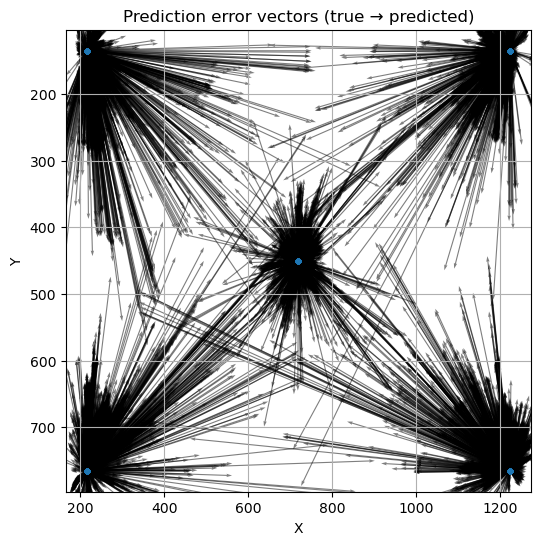

In [6]:
# Extract true coordinates
true_x = true_coords[:, 0]
true_y = true_coords[:, 1]

# Extract predicted coordinates
pred_x = pred_coords[:, 0]
pred_y = pred_coords[:, 1]

# Compute prediction errors
error_x = pred_x - true_x
error_y = pred_y - true_y

plt.figure(figsize=(6, 6))

plt.quiver(
    true_x,
    true_y,
    error_x,
    error_y,
    angles="xy",
    scale_units="xy",
    scale=1,
    alpha=0.5,
)

plt.scatter(true_x, true_y, s=10)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Prediction error vectors (true → predicted)")
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

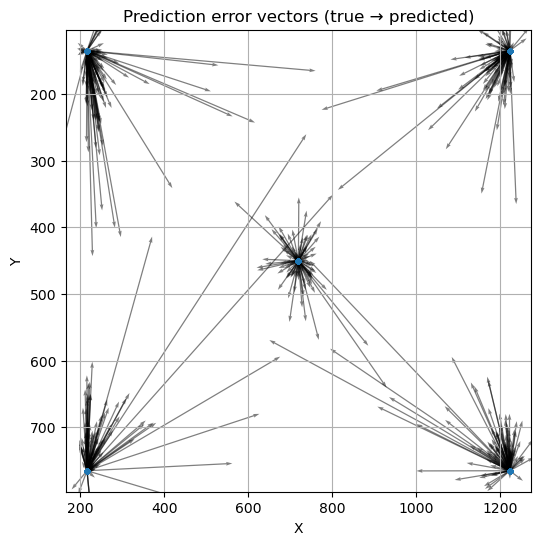

In [10]:
# Subsample
n_samples = 500
idx = np.random.choice(len(true_x), n_samples, replace=False)

plt.figure(figsize=(6, 6))

plt.quiver(
    true_x[idx],
    true_y[idx],
    error_x[idx],
    error_y[idx],
    angles="xy",
    scale_units="xy",
    scale=1,
    alpha=0.5,
)

plt.scatter(true_x[idx], true_y[idx], s=10)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Prediction error vectors (true → predicted)")
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()